In [192]:
# imports
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

In [193]:
# Exploratory analysis
diamonds = pd.read_csv("../data/diamonds.csv", index_col=0)

diamonds = diamonds.dropna()
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [194]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB


In [195]:
# Drop zero values
(diamonds[["x", "y", "z"]] == 0).sum()
i = diamonds[(diamonds[["x", "y", "z"]] == 0).any(axis=1)].index
diamonds = diamonds.drop(i)
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53920 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53920 non-null  float64
 1   cut      53920 non-null  object 
 2   color    53920 non-null  object 
 3   clarity  53920 non-null  object 
 4   depth    53920 non-null  float64
 5   table    53920 non-null  float64
 6   price    53920 non-null  int64  
 7   x        53920 non-null  float64
 8   y        53920 non-null  float64
 9   z        53920 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB


In [196]:
# Make new column x*y*z - size
diamonds["size"] = diamonds["x"] * diamonds["y"] * diamonds["z"]

# Get out high leverage points
diamonds = diamonds[diamonds["size"] < 1000]

diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,size
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250


In [197]:
diamonds.describe()

,carat,depth,table,price,x,y,z,size
count,53919.000000,53919.000000,53919.000000,53919.000000,53919.000000,53919.000000,53919.000000,53919.000000
mean,0.797676,61.749567,57.456843,3930.839685,5.731583,5.733901,3.539963,129.828747
std,0.473771,1.432292,2.234084,3987.158006,1.119387,1.116910,0.702267,76.570682
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000,31.707984
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000,65.189349
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,114.840180
75%,1.040000,62.500000,59.000000,5322.500000,6.540000,6.540000,4.040000,170.845492
max,5.010000,79.000000,95.000000,18823.000000,10.740000,31.800000,31.800000,838.502400


In [198]:
# Model
n = len(diamonds)

# Definition of category order
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
# Ordinal encoding - transfer of categories to number codes
diamonds["cut_encoded"] = diamonds["cut"].apply(lambda x: cut_order.index(x))
diamonds["clarity_encoded"] = diamonds["clarity"].apply(lambda x: clarity_order.index(x))
diamonds["color_encoded"] = diamonds["color"].apply(lambda x: color_order.index(x))


diamonds["size"] = np.log(diamonds["size"])

X = diamonds[["size", "cut_encoded", "clarity_encoded", "color_encoded"]]
X = sm.add_constant(X)
y = np.log(diamonds["price"])

# Test/train split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = sm.OLS(y_train, X_train).fit()
fitted = model.fittedvalues

resid = y_train - fitted

fitted_test = model.predict(X_test)

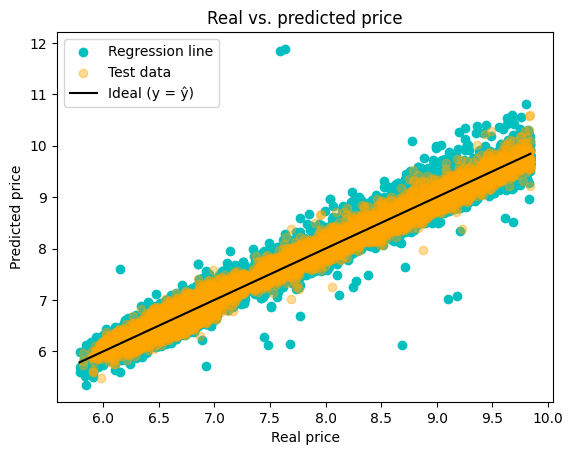

In [ ]:
# Linear regression graph
plt.scatter(y_train, fitted, color="c", label="Train data")
plt.scatter(y_test, fitted_test, color="orange", alpha=0.4, label="Test data")
plt.xlabel("Real price")
plt.ylabel("Predicted price")
plt.title("Real vs. predicted price")
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color="k", label="Ideal (y = ŷ)")
plt.legend()
plt.show()

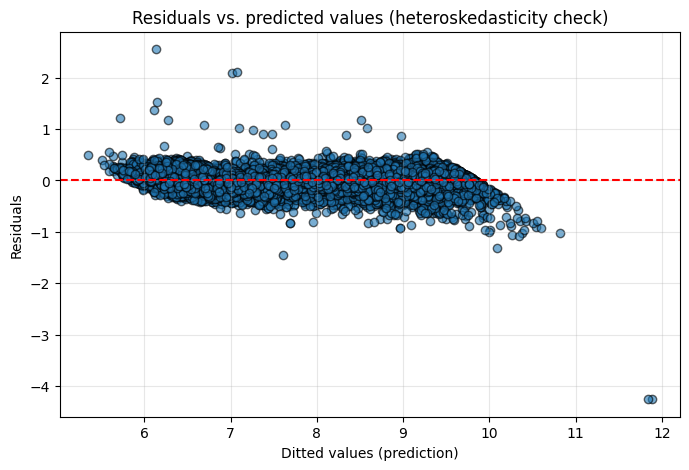

In [200]:
# Heteroskedasticity
plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid, alpha=0.6, edgecolors="k")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Ditted values (prediction)")
plt.ylabel("Residuals")
plt.title("Residuals vs. predicted values (heteroskedasticity check)")
plt.grid(True, alpha=0.3)
plt.show()

In [201]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                 4.604e+05
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        08:44:46   Log-Likelihood:                 19633.
No. Observations:               43135   AIC:                        -3.926e+04
Df Residuals:                   43130   BIC:                        -3.921e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.7793      0.008   -211.140      0.000      -1.796      -1.763
size                1.8881      0.001   1304.590      0.000       1.885       1.891
cut_encoded         0.0207      0.001     30.525      0.000       0.019       0.022
clarity_encoded     0.1207      0.000    243.410      0.000       0.120       0.122
color_encoded       0.0770      0.000    169.536      0.000       0.076       0.078
==============================================================================
Omnibus:                    17673.198   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1924099.002
Skew:                          -1.002   Prob(JB):                         0.00
Kurtosis:                      35.658   Cond. No.                         84.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [202]:
# Train metrics
resid_train = y_train - fitted
RMSE_train = math.sqrt((resid_train**2).mean())
MAE_train = resid_train.abs().mean()

# Test metrics
resid_test = y_test - fitted_test
RMSE_test = math.sqrt((resid_test**2).mean())
MAE_test = resid_test.abs().mean()

print(f"Train: MAE={MAE_train:.4f}, RMSE={RMSE_train:.4f}")
print(f"Test: MAE={MAE_test:.4f}, RMSE={RMSE_test:.4f}")

Train: MAE=0.1162, RMSE=0.1535
Test: MAE=0.1153, RMSE=0.1474


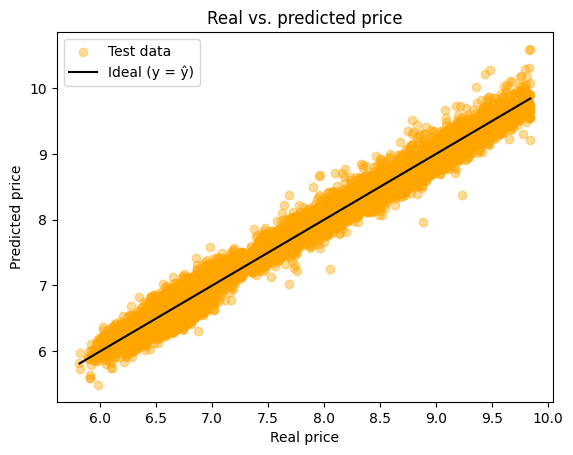

In [203]:
# Final test data - linear regression graph
plt.scatter(y_test, fitted_test, color="orange", alpha=0.4, label="Test data")
plt.xlabel("Real price")
plt.ylabel("Predicted price")
plt.title("Real vs. predicted price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="k", label="Ideal (y = ŷ)")
plt.legend()
plt.show()

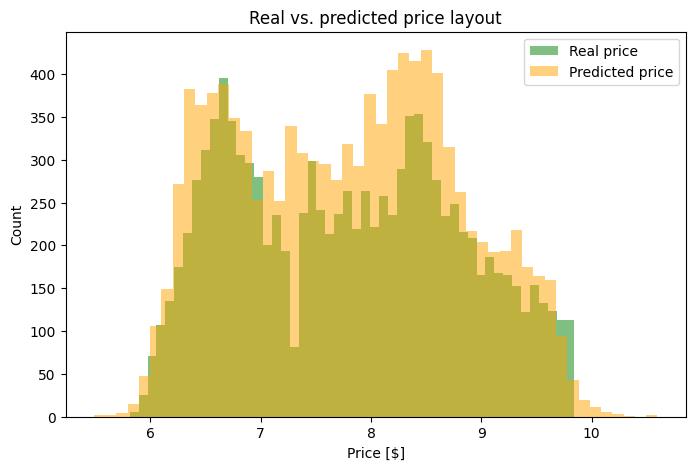

In [204]:
plt.figure(figsize=(8,5))
plt.hist(y_test, bins=50, alpha=0.5, label="Real price", color="green")
plt.hist(fitted_test, bins=50, alpha=0.5, label="Predicted price", color="orange")
plt.xlabel("Price [$]")
plt.ylabel("Count")
plt.title("Real vs. predicted price layout")
plt.legend()
plt.show()